## Inicio

### Importamos librerias

Primero, clonaremos tu repositorio de GitHub en el entorno de Colab:

In [1]:
!git clone https://github.com/ichiP245/micrography-imgpro.git

fatal: destination path 'micrography-imgpro' already exists and is not an empty directory.


Luego, agregaremos la carpeta del repositorio al `sys.path` de Python para que podamos importar el módulo `getmeresults`.

In [2]:
import sys
sys.path.append('/content/micrography-imgpro')

# Verifica que el módulo esté en la ruta antes de intentar importarlo
print("Python path updated. Trying to import getmeresults...")

Python path updated. Trying to import getmeresults...


Importamos librerías

In [4]:
import getmeresults as gmr
import cv2
import matplotlib.pyplot as plt
import os
import pandas as pd

### Definimos funciones

In [5]:
# Funciones que vamos a usar

# Esta es para recortar la parte de abajo de las imagenes que es la etiqueta con los datos, o sea algo que debemos quitar
def read_and_crop_image(path):
    import cv2, numpy as np
    img = cv2.imread(path)
    h, w = img.shape[:2]
    img = img[:h-290, :, :]  # or use auto-detection like above
    return img

def getSegmentationFigure(segmentation, percentages, filename, ax=None):
    if ax is None:
        fig = plt.figure(figsize=(14, 8))
        ax = fig.add_subplot(111)

    im = ax.imshow(segmentation)
    ax.axis('off')

    # Agregar la barra de color con etiquetas personalizadas
    cbar = fig.colorbar(im, ax=ax, orientation="vertical", shrink=0.4)
    cbar.set_ticks([20,60,150,250])
    cbar.set_ticklabels([
        f"Indefinido - {percentages['undefined']:.2f}%",
        f"Poros - {percentages['pores']:.2f}%",
        f"Resina - {percentages['resin']:.2f}%",
        f"Fibra - {percentages['fibers']:.2f}%"
        ])
    ax.set_title(f"Segmentación - {filename}")
    plt.tight_layout()

def getColoringFigure(coloring, filename):
    fig = plt.figure(figsize=(14, 8))
    plt.imshow(coloring,vmin=0,vmax=255)
    plt.axis('off')
    plt.title(f"Coloración - {filename}")
    plt.tight_layout()

In [6]:
def clean_path_image(path_image):
  return path_image.split('/')[-1]

In [7]:
def saveFigures(batch_folder_name, filename, percentages, segmentation, coloring):

    savings_folder = f"/content/drive/MyDrive/Rocketry ITBA/ProcImgs - Isidro01/{batch_folder_name}"

    if os.path.isdir(savings_folder) == False:
        raise Exception(f"La carpeta {savings_folder} no existe")

    # Figuras de segmentación
    getSegmentationFigure(segmentation, percentages, filename)

    fname = os.path.join(savings_folder, f'seg-{filename}')
    plt.savefig(fname=fname)
    plt.close()

    # Figuras de coloración
    getColoringFigure(coloring, filename)
    fname = os.path.join(savings_folder, f'col-{filename}')
    plt.savefig(fname=fname)
    plt.close()

Definimos los nombres que vamos a pasarle a la funcion del guardado de imagenes

In [8]:
# Estos son los batch_folder_names para pasar despues a la funcion de guardado de imagenes
aletas = 'Aletas - Micrografía Aletas FC 15 4 2025'
tubos2024 = 'Tubos 2024 - Micrografía M2 31 3 2025'
tubos2025simil26 = 'Tubos 2025 simil 26 - Micrografía PR2 02 2025'
tubos2025final = 'Tubos 2025 final - Micrografía Tubo F2 4 4 2025'

## Prueba inicial

Hacemos una prueba con una imagen subida al GitHub.

Los resultados son parecidos pero no iguales, ademas porque en el GitHub se le pusieron otras etiquetas a la composicion del tubo de fibra de vidrio.

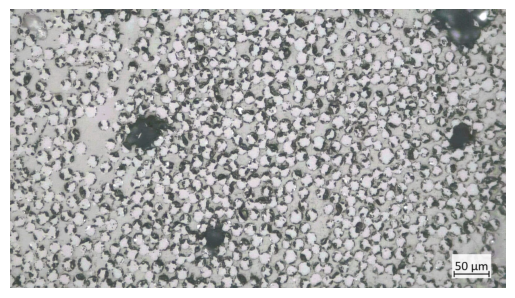

In [ ]:
imagen_prueba = cv2.imread('/content/frb-003.jpg')

if imagen_prueba is None:
    print("Error: Could not load image. Please check the path and file existence.")
else:
    # Convert BGR image to RGB for matplotlib display
    imagen_prueba_rgb = cv2.cvtColor(imagen_prueba, cv2.COLOR_BGR2RGB)
    plt.imshow(imagen_prueba_rgb)
    plt.axis('off')
    plt.show()

grayscale_image = cv2.cvtColor(imagen_prueba, cv2.COLOR_RGB2GRAY)
perc, seg, col = gmr.getMeResults(grayscale_image)

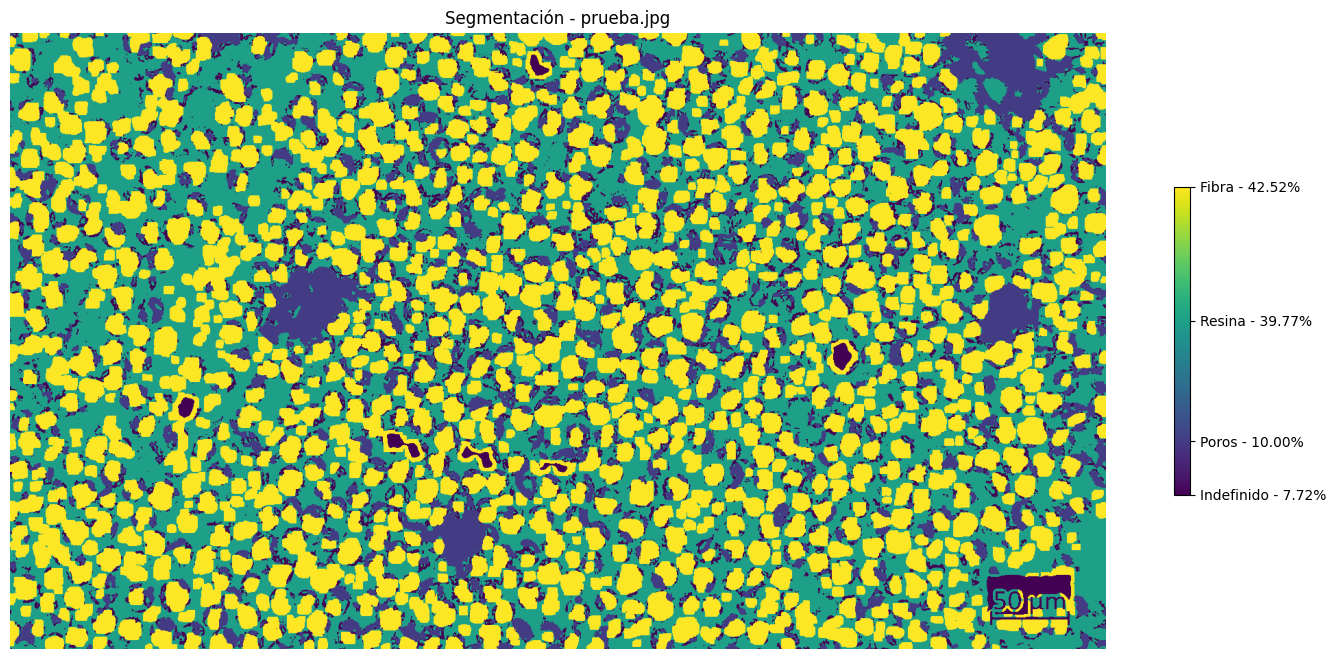

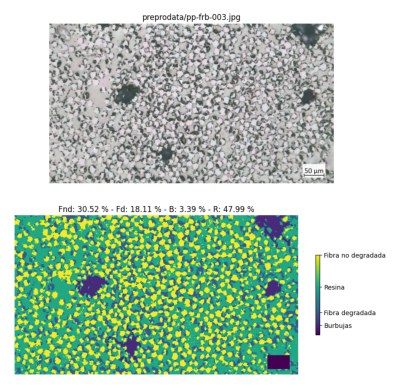

In [ ]:
getSegmentationFigure(seg, perc, 'prueba.jpg')
plt.show()

comparacion_rgb = cv2.cvtColor(cv2.imread('/content/Comparacion.png'), cv2.COLOR_BGR2RGB)
plt.imshow(comparacion_rgb)
plt.axis('off')
plt.show()

## Comienzo de preprocesamiento

Empezamos a hacer nuestro analisis

Importamos imagenes con Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Definimos parametros

In [10]:
global_parameters = {
    'first_kernel_size': (5,5),
    'second_kernel_size': (3,3),
    'contours_mult': 2.5,
    'bh_ks': (7,7),
    'bhm_iter': 4,
    'bhm_mult': 60,
    'cont_mult': 2.5,
    'ws_ths_factor': 0.025,
    'ws_gl_vecinity': 15}

## Tanda 2024

### Preprocesamiento inicial

In [10]:
# Carpeta en Google Drive -> Tubo 2024
folder_path = '/content/drive/MyDrive/Micrografía M2 31 3 2025'
folder_path = '/content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025' # Actualizado porque lo meti dentro de la carpeta Rocketry
list_path_imgs = []
for item_name in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item_name)
    if os.path.isfile(item_path):
        if len(item_name) < 22:
          print(f"File: {item_name} not added")
        else:
          list_path_imgs.append(item_path)
    elif os.path.isdir(item_path):
        print(f"Directory: {item_name}")

File: Experiment-769.jpg not added
File: Resina.jpg not added
File: Experiment-814.jpg not added


Vemos que las imagenes recortadas no hayan sacado contenido, sino unicamente el margen inferior que no sirve

In [ ]:
# Esta celda la comentamos. Al correrla vemos para cada imagen que tenemos que recortar,
# "la imagen original - la imagen recortada". Al correrlo comprobamos que estan bien recortadas

# for img_path in list_path_imgs:
#     # Read the original image
#     original_img = cv2.imread(img_path)

#     # Get the cropped image using the defined function
#     cropped_img = read_and_crop_image(img_path)

#     # Convert images from BGR to RGB for matplotlib display
#     original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
#     cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

#     # Display original and cropped images side-by-side
#     plt.figure(figsize=(15, 7))

#     plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
#     plt.imshow(original_img_rgb)
#     plt.title(f"Original: {os.path.basename(img_path)}")
#     plt.axis('off')

#     plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
#     plt.imshow(cropped_img_rgb)
#     plt.title("Recortada")
#     plt.axis('off')

#     plt.show()

# # Todas las imagenes quedaron bien recortadas

Guardamos las imagenes

In [12]:
list_cropped_imgs = []
for img_path in list_path_imgs:
  # Recortamos la imagen
  cropped_img = read_and_crop_image(img_path)
  cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2GRAY)
  list_cropped_imgs.append(cropped_img_rgb)

### Guardado resultados df

Volvemos a definir getMeResults para que no calcule la parte de segmentacion y coloracion que no vamos a usar. Solo quiero que me devuelva los porcentajes

In [ ]:
import cv2
import numpy as np

import getmepores as gmp
import getmeflashes as gmfl
import getmefibers as gmf

def getMeResults_bis(base_img, parameters = {
    'first_kernel_size': (5,5),
    'second_kernel_size': (3,3),
    'contours_mult': 2.5,
    'bh_ks': (7,7),
    'bhm_iter': 4,
    'bhm_mult': 60,
    'cont_mult': 2.5,
    'ws_ths_factor': 0.025,
    'ws_gl_vecinity': 15,
}):

    pores_mask, undefined_mask = gmp.getMetPores(base_img,
                                                first_kernel_size=parameters['first_kernel_size'],
                                                second_kernel_size=parameters['second_kernel_size'])

    flashes_mask = gmfl.getMeFlashes(base_img,cont_mult=parameters['cont_mult'])

    fibers_mask, _, _ = gmf.getMeFibers(base_img,bh_ks=parameters['bh_ks'],
                                        bhm_iter=parameters['bhm_iter'],
                                        bhm_mult=parameters['bhm_mult'],
                                        cont_mult=parameters['cont_mult'],
                                        ws_ths_factor=parameters['ws_ths_factor'],
                                        ws_gl_vecinity=parameters['ws_gl_vecinity'])

    # Se completa la máscara de objetos indefinidos
    undefined_mask_complete = np.zeros(np.shape(base_img), dtype=np.uint8)
    undefined_mask_complete[undefined_mask == 255] = 255
    undefined_mask_complete[flashes_mask == 255] = 255

    # Se refina la máscara de fibras
    fibers_mask_complete = fibers_mask.copy()
    fibers_mask_complete[pores_mask == 255] = 0
    fibers_mask_complete[undefined_mask_complete == 255] = 0

    # Se obtiene la máscara de resina y se refina
    resin_mask = cv2.bitwise_not(fibers_mask_complete)
    resin_mask[pores_mask == 255] = 0
    resin_mask[undefined_mask_complete == 255] = 0

    # Cálculos
    total_pixels = base_img.shape[0] * base_img.shape[1]
    total_pores = np.sum(pores_mask == 255)
    total_fibers = np.sum(fibers_mask_complete == 255)
    total_resin = np.sum(resin_mask == 255)
    total_undefined = np.sum(undefined_mask_complete == 255)

    percentages = {
        'pores': (total_pores / total_pixels) * 100,
        'fibers': (total_fibers / total_pixels) * 100,
        'resin': (total_resin / total_pixels) * 100,
        'undefined': (total_undefined / total_pixels) * 100,
        'sumcheck': (total_pores + total_fibers + total_resin + total_undefined) / total_pixels * 100
    }

    return percentages

Obtenemos para cada imagen los porcentajes de cada uno de los componentes y lo guardamos en un diccionario con el path de la imagen como clave.

Tarda aprox 1 minuto por imagen en calcular los porcentajes

In [ ]:
dict_results = dict()
for i in range(len(list_path_imgs)):
  path_image = list_path_imgs[i]
  grayscale_image = list_cropped_imgs[i]
  perc = getMeResults_bis(grayscale_image, global_parameters)
  dict_results[path_image] = perc
  print(f"Image number {i}: {list_path_imgs[i]} COMPLETED")

Image number 0: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--02.jpg COMPLETED
Image number 1: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--01.jpg COMPLETED
Image number 2: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--07.jpg COMPLETED
Image number 3: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--06.jpg COMPLETED
Image number 4: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--04.jpg COMPLETED
Image number 5: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--03.jpg COMPLETED
Image number 6: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--05.jpg COMPLETED
Image number 7: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--11.jpg COMPLETED
Image number 8: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--09.jpg COMPLETED
Image number 9: /content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--12.jpg COMPLETED
Image number 10: /co

Lo guardamos en un dataframe y lo descargamos

In [ ]:
df_results24 = pd.DataFrame(dict_results).T

In [ ]:
df_results24.reset_index(inplace=True)
df_results24.rename(columns={'index': 'Image Paths'}, inplace=True)

In [ ]:
df_results24['Tanda'] = 'Tubos 2024'

In [ ]:
# df_results24.to_csv('df_results24.csv')

In [ ]:
df_results24.head()

,Image Paths,pores,fibers,resin,undefined,sumcheck,Tanda
0,/content/drive/MyDrive/Micrografía M2 31 3 20...,0.000000,29.094329,64.121528,6.784144,100.0,Tubos 2024
1,/content/drive/MyDrive/Micrografía M2 31 3 20...,1.867573,64.227527,30.862606,3.042294,100.0,Tubos 2024
2,/content/drive/MyDrive/Micrografía M2 31 3 20...,6.011863,33.776427,53.767458,6.444252,100.0,Tubos 2024
3,/content/drive/MyDrive/Micrografía M2 31 3 20...,5.026331,34.344522,54.051119,6.578029,100.0,Tubos 2024
4,/content/drive/MyDrive/Micrografía M2 31 3 20...,0.000000,30.568528,63.969811,5.461661,100.0,Tubos 2024


In [ ]:
df_results24['Image Paths'][0]

'/content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--02.jpg'

In [ ]:
list_path_imgs[0]

'/content/drive/MyDrive/Micrografía M2 31 3 2025/Experiment-769--02.jpg'

### Guardado resultados imagenes

Supuestamente tardo 32 minutos, pero hubo un corte de ejecucion cuando iban 10. Asi que mas o menos 40 minutos, un poco mas. Promedio de 1 minuto por imagen

In [53]:
for i in range(len(list_path_imgs)):
  path_image = list_path_imgs[i]
  grayscale_image = list_cropped_imgs[i]
  percentages, segmentation, coloring = gmr.getMeResults(grayscale_image, global_parameters)
  filename = clean_path_image(path_image)
  saveFigures(tubos2024, filename, percentages, segmentation, coloring)

  print(f"Image number {i}: {list_path_imgs[i]} UPLOADED - Missing {len(list_path_imgs)-i-1}")

Image number 0: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--02.jpg UPLOADED - Missing 46
Image number 1: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--01.jpg UPLOADED - Missing 45
Image number 2: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--07.jpg UPLOADED - Missing 44
Image number 3: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--06.jpg UPLOADED - Missing 43
Image number 4: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--04.jpg UPLOADED - Missing 42
Image number 5: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--03.jpg UPLOADED - Missing 41
Image number 6: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--05.jpg UPLOADED - Missing 40
Image number 7: /content/drive/MyDrive/Rocketry ITBA/Micrografía M2 31 3 2025/Experiment-769--11.jpg UPLOADED - Missing 39
Image nu

## Tanda 2025 (simil 2026)

### Preprocesamiento inicial

In [11]:
folder_path2 = '/content/drive/MyDrive/Micrografía PR2 02 2025'
folder_path2 = '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025' # Actualizada
list_path_imgs_2 = []
for item_name in os.listdir(folder_path2):
    item_path = os.path.join(folder_path2, item_name)
    if os.path.isfile(item_path):
        list_path_imgs_2.append(item_path)
    elif os.path.isdir(item_path):
        print(f"Directory: {item_name}")

In [12]:
list_path_imgs_2 = [path for path in list_path_imgs_2 if 'jpg' in path]
list_path_imgs_2.remove('/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--13.jpg') # Actualice los paths porque faltaba el "/Rocketry ITBA"
list_path_imgs_2.remove('/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--18.jpg')
list_path_imgs_2.remove('/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--22.jpg')
list_path_imgs_2

['/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--03.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--01.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--02.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--08.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--09.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--05.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--06.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--04.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--07.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--12.jpg',
 '/content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--10.jpg',
 '/content

In [13]:
# Quedamos con ... imagenes
len(list_path_imgs_2)

24

In [ ]:
# Esta celda la comentamos. Al correrla vemos para cada imagen que tenemos que recortar,
# "la imagen original - la imagen recortada". Al correrlo comprobamos que estan bien recortadas

# for img_path in list_path_imgs_2:
#     # Read the original image
#     original_img = cv2.imread(img_path)

#     # Get the cropped image using the defined function
#     cropped_img = read_and_crop_image(img_path)

#     # Convert images from BGR to RGB for matplotlib display
#     original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
#     cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

#     # Display original and cropped images side-by-side
#     plt.figure(figsize=(15, 7))

#     plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
#     plt.imshow(original_img_rgb)
#     plt.title(f"Original: {os.path.basename(img_path)}")
#     plt.axis('off')

#     plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
#     plt.imshow(cropped_img_rgb)
#     plt.title("Recortada")
#     plt.axis('off')

#     plt.show()

# # Todas las imagenes quedaron bien recortadas

In [14]:
list_cropped_imgs_2 = []
for img_path in list_path_imgs_2:
  # Recortamos la imagen
  cropped_img = read_and_crop_image(img_path)
  cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2GRAY)
  list_cropped_imgs_2.append(cropped_img_rgb)

In [15]:
len(list_cropped_imgs_2) == len(list_path_imgs_2)

True

### Guardado resultados df

In [ ]:
dict_results2 = dict()
for i in range(len(list_path_imgs_2)):
  path_image = list_path_imgs_2[i]
  grayscale_image = list_cropped_imgs_2[i]
  perc = getMeResults_bis(grayscale_image, global_parameters)
  dict_results2[path_image] = perc
  print(f"Image number {i}: {list_path_imgs_2[i]} COMPLETED")

Image number 0: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--02.jpg COMPLETED
Image number 1: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--16.jpg COMPLETED
Image number 2: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--14.jpg COMPLETED
Image number 3: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--15.jpg COMPLETED
Image number 4: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--12.jpg COMPLETED
Image number 5: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--11.jpg COMPLETED
Image number 6: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--10.jpg COMPLETED
Image number 7: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--09.jpg COMPLETED
Image number 8: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--06.jpg COMPLETED
Image number 9: /content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--07.jpg COMPLETED
Image number 10: /co

In [ ]:
df_results25simil26 = pd.DataFrame(dict_results2).T
df_results25simil26.reset_index(inplace=True)
df_results25simil26.rename(columns={'index': 'Image Paths'}, inplace=True)
df_results25simil26['Tanda'] = 'Tubos 2025 (similar a version 2026)'

In [ ]:
df_results25simil26.head()

,Image Paths,pores,fibers,resin,undefined,sumcheck,Tanda
0,/content/drive/MyDrive/Micrografía PR2 02 202...,3.820505,29.307002,50.458333,16.414159,100.0,Tubos 2025 (similar a version 2026)
1,/content/drive/MyDrive/Micrografía PR2 02 202...,7.740837,45.964892,38.848476,7.445795,100.0,Tubos 2025 (similar a version 2026)
2,/content/drive/MyDrive/Micrografía PR2 02 202...,11.336468,28.045573,50.946229,9.671730,100.0,Tubos 2025 (similar a version 2026)
3,/content/drive/MyDrive/Micrografía PR2 02 202...,6.883295,27.198351,50.628906,15.289448,100.0,Tubos 2025 (similar a version 2026)
4,/content/drive/MyDrive/Micrografía PR2 02 202...,4.581067,21.271557,53.821422,20.325955,100.0,Tubos 2025 (similar a version 2026)


In [ ]:
# df_results25simil26.to_csv('df_results25simil26.csv')

In [ ]:
df_results25simil26['Image Paths'][0]

'/content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--02.jpg'

In [ ]:
list_path_imgs_2[0]

'/content/drive/MyDrive/Micrografía PR2 02 2025/Experiment-1126--02.jpg'

### Guardado resultados imagenes

In [23]:
for i in range(len(list_path_imgs_2)):
  path_image = list_path_imgs_2[i]
  grayscale_image = list_cropped_imgs_2[i]
  percentages, segmentation, coloring = gmr.getMeResults(grayscale_image, global_parameters)
  filename = clean_path_image(path_image)
  saveFigures(tubos2025simil26, filename, percentages, segmentation, coloring)    # Acordarse de cambiar el batch folder name

  print(f"Image number {i}: {list_path_imgs_2[i]} UPLOADED - Missing {len(list_path_imgs_2)-i-1}")

Image number 0: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--03.jpg UPLOADED - Missing 23
Image number 1: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--01.jpg UPLOADED - Missing 22
Image number 2: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--02.jpg UPLOADED - Missing 21
Image number 3: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--08.jpg UPLOADED - Missing 20
Image number 4: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--09.jpg UPLOADED - Missing 19
Image number 5: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--05.jpg UPLOADED - Missing 18
Image number 6: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--06.jpg UPLOADED - Missing 17
Image number 7: /content/drive/MyDrive/Rocketry ITBA/Micrografía PR2 02 2025/Experiment-1126--04.jpg UPLOADED - Missing 16
Image nu

In [28]:
# Verificamos que la carpeta tenga la cantidad de archivos que corresponden (2 por cada imagen -1 de coloracion y 1 de segmentacion-)
len(os.listdir('/content/drive/MyDrive/Rocketry ITBA/ProcImgs - Isidro01/Tubos 2025 simil 26 - Micrografía PR2 02 2025'))

48

## Tanda 2025 (cercana a la final)

### Preprocesamiento inicial

In [29]:
folder_path3 = '/content/drive/MyDrive/Micrografía Tubo F2 4 4 2025'
folder_path3 = '/content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025' # Actualizamos
list_path_imgs_3 = []
for item_name in os.listdir(folder_path3):
    item_path = os.path.join(folder_path3, item_name)
    if os.path.isfile(item_path):
        list_path_imgs_3.append(item_path)
    elif os.path.isdir(item_path):
        print(f"Directory: {item_name}")

In [30]:
print('Longitud inicial:', len(list_path_imgs_3))
list_path_imgs_3 = [item for item in list_path_imgs_3 if '820' in item]
print('Longitud final (post eliminar las 2 imagenes que no eran del Experimento 820):', len(list_path_imgs_3))

Longitud inicial: 14
Longitud final (post eliminar las 2 imagenes que no eran del Experimento 820): 12


In [ ]:
# # Esta celda la comentamos. Al correrla vemos para cada imagen que tenemos que recortar,
# # "la imagen original - la imagen recortada". Al correrlo comprobamos que estan bien recortadas

# for img_path in list_path_imgs_3:
#     # Read the original image
#     original_img = cv2.imread(img_path)

#     # Get the cropped image using the defined function
#     cropped_img = read_and_crop_image(img_path)

#     # Convert images from BGR to RGB for matplotlib display
#     original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
#     cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

#     # Display original and cropped images side-by-side
#     plt.figure(figsize=(15, 7))

#     plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
#     plt.imshow(original_img_rgb)
#     plt.title(f"Original: {os.path.basename(img_path)}")
#     plt.axis('off')

#     plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
#     plt.imshow(cropped_img_rgb)
#     plt.title("Recortada")
#     plt.axis('off')

#     plt.show()

# # Todas las imagenes quedaron bien recortadas

In [32]:
list_cropped_imgs_3 = []
for img_path in list_path_imgs_3:
  # Recortamos la imagen
  cropped_img = read_and_crop_image(img_path)
  cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_RGB2GRAY)
  list_cropped_imgs_3.append(cropped_img_rgb)

In [33]:
len(list_cropped_imgs_3) == len(list_path_imgs_3)

True

In [34]:
len(list_path_imgs_3)

12

### Guardado resultados df

In [ ]:
dict_results3 = dict()
for i in range(len(list_path_imgs_3)):
  path_image = list_path_imgs_3[i]
  grayscale_image = list_cropped_imgs_3[i]
  perc = getMeResults_bis(grayscale_image, global_parameters)
  dict_results3[path_image] = perc
  print(f"Image number {i}: {list_path_imgs_3[i]} COMPLETED")

Image number 0: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--03.jpg COMPLETED
Image number 1: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--12.jpg COMPLETED
Image number 2: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--07.jpg COMPLETED
Image number 3: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--13.jpg COMPLETED
Image number 4: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--11.jpg COMPLETED
Image number 5: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--08.jpg COMPLETED
Image number 6: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--06.jpg COMPLETED
Image number 7: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--02.jpg COMPLETED
Image number 8: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--05.jpg COMPLETED
Image number 9: /content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-82

In [ ]:
df_results25cercano = pd.DataFrame(dict_results3).T
df_results25cercano.reset_index(inplace=True)
df_results25cercano.rename(columns={'index': 'Image Paths'}, inplace=True)
df_results25cercano['Tanda'] = 'Tubos 2025 (cercana a la final)'

In [ ]:
# df_results25cercano.to_csv('df_results25cercano.csv')

In [ ]:
df_results25cercano.head()

,Image Paths,pores,fibers,resin,undefined,sumcheck,Tanda
0,/content/drive/MyDrive/Micrografía Tubo F2 4 ...,5.662423,50.493393,41.995611,1.848573,100.0,Tubos 2025 (cercana a la final)
1,/content/drive/MyDrive/Micrografía Tubo F2 4 ...,2.664448,56.736304,37.814815,2.784433,100.0,Tubos 2025 (cercana a la final)
2,/content/drive/MyDrive/Micrografía Tubo F2 4 ...,4.713445,49.414304,43.747155,2.125096,100.0,Tubos 2025 (cercana a la final)
3,/content/drive/MyDrive/Micrografía Tubo F2 4 ...,0.002411,38.644531,60.940731,0.412326,100.0,Tubos 2025 (cercana a la final)
4,/content/drive/MyDrive/Micrografía Tubo F2 4 ...,2.009983,52.405237,43.343123,2.241657,100.0,Tubos 2025 (cercana a la final)


In [ ]:
df_results25cercano['Image Paths'][0]

'/content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--03.jpg'

In [ ]:
list_path_imgs_3[0]

'/content/drive/MyDrive/Micrografía Tubo F2 4 4 2025/Experiment-820--03.jpg'

### Guardado resultados imagenes

In [38]:
for i in range(len(list_path_imgs_3)):
  path_image = list_path_imgs_3[i]
  grayscale_image = list_cropped_imgs_3[i]
  percentages, segmentation, coloring = gmr.getMeResults(grayscale_image, global_parameters)
  filename = clean_path_image(path_image)
  saveFigures(tubos2025final, filename, percentages, segmentation, coloring)    # Acordarse de cambiar el batch folder name

  print(f"Image number {i}: {list_path_imgs_3[i]} UPLOADED - Missing {len(list_path_imgs_3)-i-1}")

Image number 0: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--01.jpg UPLOADED - Missing 11
Image number 1: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--02.jpg UPLOADED - Missing 10
Image number 2: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--03.jpg UPLOADED - Missing 9
Image number 3: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--04.jpg UPLOADED - Missing 8
Image number 4: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--08.jpg UPLOADED - Missing 7
Image number 5: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--09.jpg UPLOADED - Missing 6
Image number 6: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--06.jpg UPLOADED - Missing 5
Image number 7: /content/drive/MyDrive/Rocketry ITBA/Micrografía Tubo F2 4 4 2025/Experiment-820--05.jpg UPL

In [40]:
# Confirmamos que la cantidad sea la correcta
len(os.listdir('/content/drive/MyDrive/Rocketry ITBA/ProcImgs - Isidro01/Tubos 2025 final - Micrografía Tubo F2 4 4 2025'))

24

# Aletas

### Preprocesamiento inicial

In [41]:
folder_path_aletas = '/content/drive/MyDrive/Micrografía Aletas FC 15 4 2025'
folder_path_aletas = '/content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025' # Actualizado
list_path_aletas = []
for item_name in os.listdir(folder_path_aletas):
    item_path = os.path.join(folder_path_aletas, item_name)
    if os.path.isfile(item_path):
        list_path_aletas.append(item_path)
    elif os.path.isdir(item_path):
        print(f"Directory: {item_name}")

In [42]:
len(list_path_aletas)

17

In [ ]:
# # Esta celda la comentamos. Al correrla vemos para cada imagen que tenemos que recortar,
# # "la imagen original - la imagen recortada". Al correrlo comprobamos que estan bien recortadas

# for img_path in list_path_aletas:
#     # Read the original image
#     original_img = cv2.imread(img_path)

#     # Get the cropped image using the defined function
#     cropped_img = read_and_crop_image(img_path)

#     # Convert images from BGR to RGB for matplotlib display
#     original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
#     cropped_img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

#     # Display original and cropped images side-by-side
#     plt.figure(figsize=(15, 7))

#     plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
#     plt.imshow(original_img_rgb)
#     plt.title(f"Original: {os.path.basename(img_path)}")
#     plt.axis('off')

#     plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
#     plt.imshow(cropped_img_rgb)
#     plt.title("Recortada")
#     plt.axis('off')

#     plt.show()

# # SOLO HAY QUE RECORTAR LA PRIMERA IMAGEN (la 872)

In [44]:
list_img_aletas = []
for img_path in list_path_aletas:
  if '872' in img_path:
    # Recortamos la imagen
    img_aleta = read_and_crop_image(img_path)
  else:
    img_aleta = cv2.imread(img_path)
  img_aleta = cv2.cvtColor(img_aleta, cv2.COLOR_RGB2GRAY)
  list_img_aletas.append(img_aleta)

In [45]:
len(list_img_aletas) == len(list_path_aletas)

True

In [46]:
len(list_path_aletas)

17

### Guardado resultados df

In [ ]:
dict_results_aletas = dict()
for i in range(len(list_path_aletas)):
  path_image = list_path_aletas[i]
  grayscale_image = list_img_aletas[i]
  perc = getMeResults_bis(grayscale_image, global_parameters)
  dict_results_aletas[path_image] = perc
  print(f"Image number {i}: {list_path_aletas[i]} COMPLETED")

Image number 0: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-872.jpg COMPLETED
Image number 1: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-873.jpg COMPLETED
Image number 2: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-874.jpg COMPLETED
Image number 3: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-878.jpg COMPLETED
Image number 4: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-879.jpg COMPLETED
Image number 5: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-880.jpg COMPLETED
Image number 6: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-881.jpg COMPLETED
Image number 7: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-884.jpg COMPLETED
Image number 8: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-885.jpg COMPLETED
Image number 9: /content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-886.jpg 

In [ ]:
df_results_aletas = pd.DataFrame(dict_results_aletas).T
df_results_aletas.reset_index(inplace=True)
df_results_aletas.rename(columns={'index': 'Image Paths'}, inplace=True)
df_results_aletas['Tanda'] = 'Aletas 1'

In [ ]:
# df_results_aletas.to_csv('df_results_aletas.csv')

In [ ]:
df_results_aletas.head()

,Image Paths,pores,fibers,resin,undefined,sumcheck,Tanda
0,/content/drive/MyDrive/Micrografía Aletas FC ...,7.981626,11.468364,76.308497,4.241512,100.0,Aletas 1
1,/content/drive/MyDrive/Micrografía Aletas FC ...,8.116898,48.704282,40.764082,2.414738,100.0,Aletas 1
2,/content/drive/MyDrive/Micrografía Aletas FC ...,21.382812,51.529610,24.885610,2.201968,100.0,Aletas 1
3,/content/drive/MyDrive/Micrografía Aletas FC ...,9.922743,7.209201,76.243200,6.624855,100.0,Aletas 1
4,/content/drive/MyDrive/Micrografía Aletas FC ...,9.658372,9.103202,74.875289,6.363137,100.0,Aletas 1


In [ ]:
df_results_aletas['Image Paths'][0]

'/content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-872.jpg'

In [ ]:
list_path_aletas[0]

'/content/drive/MyDrive/Micrografía Aletas FC 15 4 2025/Experiment-872.jpg'

### Guardado resultados imagenes

In [48]:
for i in range(len(list_path_aletas)):
  path_image = list_path_aletas[i]
  grayscale_image = list_img_aletas[i]
  percentages, segmentation, coloring = gmr.getMeResults(grayscale_image, global_parameters)
  filename = clean_path_image(path_image)
  saveFigures(aletas, filename, percentages, segmentation, coloring)    # Acordarse de cambiar el batch folder name

  print(f"Image number {i}: {list_path_aletas[i]} UPLOADED - Missing {len(list_path_aletas)-i-1}")

Image number 0: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-872.jpg UPLOADED - Missing 16
Image number 1: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-873.jpg UPLOADED - Missing 15
Image number 2: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-874.jpg UPLOADED - Missing 14
Image number 3: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-878.jpg UPLOADED - Missing 13
Image number 4: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-879.jpg UPLOADED - Missing 12
Image number 5: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-880.jpg UPLOADED - Missing 11
Image number 6: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-881.jpg UPLOADED - Missing 10
Image number 7: /content/drive/MyDrive/Rocketry ITBA/Micrografía Aletas FC 15 4 2025/Experiment-884.jpg UPLOAD